# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

## 1. Coleta de dados

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_csv("CHURN_TELECON_MOD14_TAREFA.csv")
df.head(10)

,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_telefone,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_pagamento,Pagamento_Mensal,Total_Pago,Churn
0,0,0,1,0,1,0,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,0
4,1,0,0,0,2,1,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,151.65,1
5,1,0,1,1,13,1,DSL,Yes,No,No,Month-to-month,Mailed check,71.45,587.45,0
6,1,0,0,0,16,1,No,No internet service,No internet service,No internet service,Two year,Credit card (automatic),71.45,326.80,0
7,1,0,1,0,58,1,Fiber optic,No,No,Yes,One year,Credit card (automatic),71.45,5681.10,0
8,1,0,0,0,49,1,Fiber optic,No,No,Yes,Month-to-month,Bank transfer (automatic),71.45,5036.30,1
9,1,0,0,0,25,1,Fiber optic,Yes,Yes,Yes,Month-to-month,Electronic check,71.45,2686.05,0


## 2) Análise univariada:

In [3]:
# Verificando os dados estatísticos das variáveis
df.describe()

,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_telefone,Pagamento_Mensal,Total_Pago,Churn
count,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000,2495.000000
mean,0.511423,0.161122,0.492585,0.314629,32.354309,0.965531,66.356894,2292.625812,0.260120
std,0.499970,0.367717,0.500045,0.464461,24.634007,0.182467,28.013627,2266.888527,0.438788
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.400000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,1.000000,45.550000,402.175000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,71.450000,1404.650000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,56.000000,1.000000,87.375000,3874.750000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,118.650000,8564.750000,1.000000


É possível perceber na tabela describe() que:

* As variáveis Genero, Idoso, Casado, Dependentes, Servico_telefone e Churn são binárias (0/1). Nesse caso, a média pode ser interpretada como proporção de registros com valor 1, Genero, Idoso, Casado, Dependentes, Servico_telefone e Churn, têm aproximadamente 51%, 16%, 49%, 31%, 97% e 26% de cancelamentos, respectivamente.

* Tempo_como_Cliente varia de 0 a 72 meses, com Q1=8 e Q3=56, indicando grande heterogeneidade no tempo de permanência dos clientes.

* As variáveis Tempo_como_Cliente e Total_Pago apresentam média > mediana, isso sugere cauda longa à direita (poucos clientes com valores muito altos).

* A variável Pagamento_Mensal apresenta média < mediana, sugerindo possível assimetria à esquerda, o que será confirmado com histograma/boxplot.

* O valor máximo de Total_Pago está bem acima do 3º quartil (Q3), sugerindo presença de valores extremos, o que deve ser confirmado com boxplot/IQR.

* Total_Pago apresenta alta dispersão (desvio padrão elevado) e diferença grande entre média e mediana, sugerindo distribuição bem concentrada em valores baixos e poucos clientes com valores muito altos.

### 2.1 Variável Tempo_como_Cliente 

In [4]:
#verificando quantidade de linhas com a variável Tempo_como_Cliente igual a 0
(df['Tempo_como_Cliente'] == 0).sum()

np.int64(5)

In [5]:
(df['Tempo_como_Cliente'] == 0).mean() * 100

np.float64(0.2004008016032064)

In [6]:
df['Tempo_como_Cliente'].mean()

np.float64(32.354308617234466)

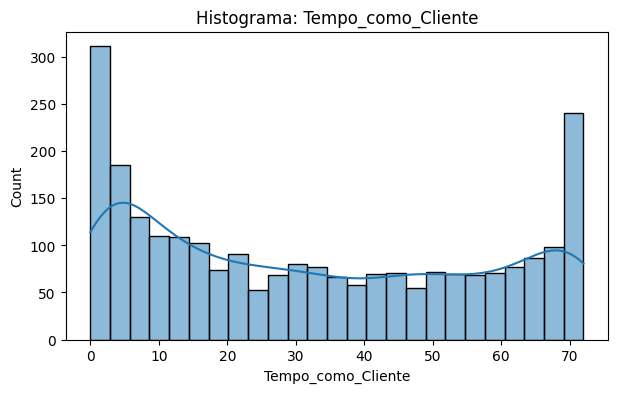

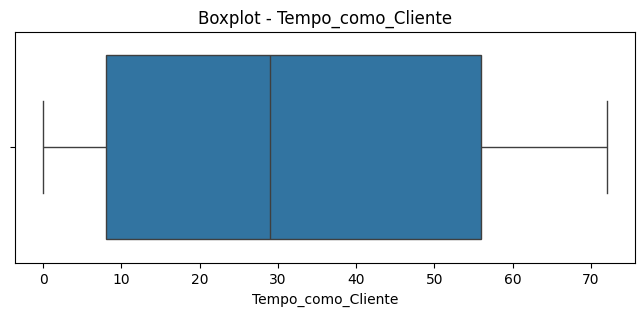

In [7]:
col = 'Tempo_como_Cliente'

plt.figure(figsize=(7,4))
sns.histplot(df[col], bins=25, kde=True)
plt.title(f'Histograma: {col}')
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=df[col])
plt.title(f'Boxplot - {col}')
plt.show()

Podemos observar que:

* O histograma mostra alta concentração de clientes com pouco tempo de casa (pico nos primeiros meses), indicando que a base contém muitos clientes recentes.
* Há também uma frequência relevante de clientes muito antigos (próximo de 70+ meses), sugerindo coexistência de dois perfis: clientes novos e clientes bem estabelecidos.
* O boxplot indica uma dispersão alta (Q1 e Q3 bem separados), o que reforça a heterogeneidade do tempo de permanência.
* Não há outliers evidentes pelo boxplot/IQR, e como o intervalo é naturalmente limitado (0–72 meses), valores altos tendem a representar clientes legítimos, não erros.

Como churn costuma ocorrer mais cedo, essa variável tende a ser muito informativa: clientes com menor Tempo_como_Cliente frequentemente apresentam maior risco de cancelamento.

### 2.2 Variável Pagamento_Mensal 

In [8]:
#verificando quantidade de linhas com a variável Tempo_como_Cliente igual a 0
(df['Pagamento_Mensal'] == 0).sum()

np.int64(0)

In [9]:
df['Pagamento_Mensal'].mean()

np.float64(66.35689378757516)

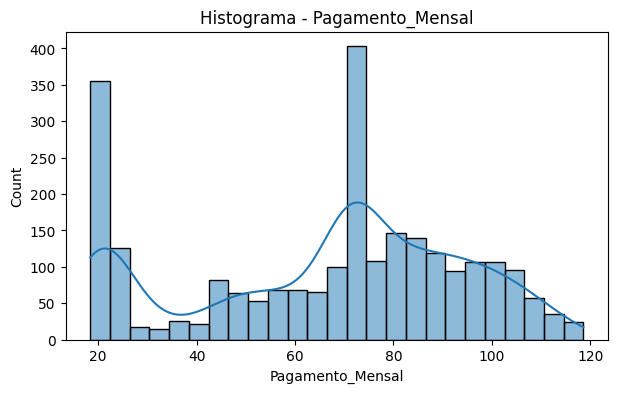

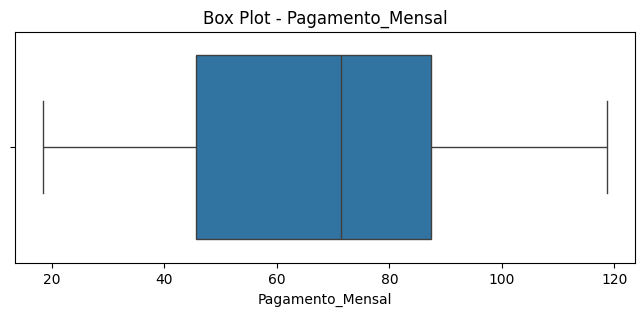

In [10]:
col = 'Pagamento_Mensal'

plt.figure(figsize=(7,4))
sns.histplot(df[col], bins=25, kde=True)
plt.title(f'Histograma - {col}')
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=df[col])
plt.title(f'Box Plot - {col}')
plt.show()

Podemos concluir que:

* O histograma sugere uma distribuição multimodal (mais de um pico), o que é típico quando existem faixas de planos diferentes (ex.: plano básico vs plano com adicionais).
* A maior densidade em torno de valores intermediários/altos sugere que muitos clientes estão em planos com serviços agregados, enquanto a cauda em valores baixos representa perfis mais básicos.
* O boxplot mostra dispersão moderada (amplitude ~18 a ~118), sem evidência forte de outliers extremos; valores altos podem ser planos premium e não necessariamente inconsistências.
* Como variável de custo recorrente, Pagamento_Mensal pode ter relação direta com churn: preços mais altos podem aumentar a probabilidade de cancelamento caso o cliente não perceba valor suficiente.

A comparação entre média e mediana sugere leve assimetria; a confirmação visual é feita pelo histograma.

### 2.3 Variável Total_Pago 

In [11]:
#verificando quantidade de linhas com a variável Tempo_como_Cliente igual a 0
(df['Total_Pago'] == 0).sum()

np.int64(0)

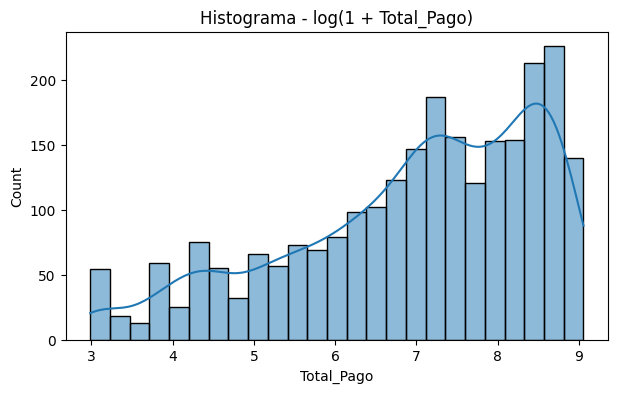

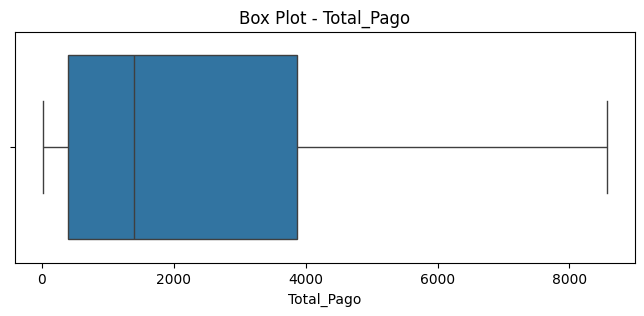

In [12]:
col = 'Total_Pago'

plt.figure(figsize=(7,4))
sns.histplot(np.log1p(df[col]), bins=25, kde=True)
plt.title(f'Histograma - log(1 + {col})')
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=df[col])
plt.title(f'Box Plot - {col}')
plt.show()

Podemos observar que:

* O histograma é fortemente assimétrico à direita: muitos clientes têm Total_Pago baixo e poucos clientes acumulam valores muito altos (cauda longa).
* Esse padrão é esperado porque Total_Pago tende a crescer com o tempo (é acumulado), então clientes antigos naturalmente aparecem com valores maiores.
* O boxplot reforça a presença de valores extremos (grande distância até o máximo), que podem ser interpretados como clientes com muito tempo de contrato e/ou maior gasto mensal, não necessariamente erros.
* Para melhor visualização, foi aplicado **log(1 + Total_Pago)** no histograma, pois a variável é altamente assimétrica.

# 3) Tratando os outliers.

In [13]:
def iqr_limits(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    return q1, q3, iqr, lower_limit, upper_limit

cols_num = ['Tempo_como_Cliente', 'Pagamento_Mensal', 'Total_Pago']

for col in cols_num:
    q1, q3, iqr, lower_limit, upper_limit = iqr_limits(df[col])
    qtd_outliers = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    print(f"{col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, limites=({lower_limit:.2f}, {upper_limit:.2f}), outliers={qtd_outliers}")

Tempo_como_Cliente: Q1=8.00, Q3=56.00, IQR=48.00, limites=(-64.00, 128.00), outliers=0
Pagamento_Mensal: Q1=45.55, Q3=87.38, IQR=41.83, limites=(-17.19, 150.11), outliers=0
Total_Pago: Q1=402.18, Q3=3874.75, IQR=3472.57, limites=(-4806.69, 9083.61), outliers=0


Por meio dos resultados aplicando o método do IQR nas variáveis numéricas Tempo_como_Cliente, Pagamento_Mensal e Total_Pago. Em todas elas, a quantidade de outliers encontrados foi 0, pois os limites inferior e superior calculados englobam todos os valores observados. Portanto, não foi necessário remover ou modificar registros por outliers. Apesar de Total_Pago apresentar forte assimetria à direita (cauda longa), isso parece refletir um comportamento esperado de variável acumulada (clientes com mais tempo pagando), e não valores atípicos fora do critério estatístico.

Como alternativa para lidar com a assimetria em etapas futuras, pode-se aplicar transformação logarítmica ou escalonamento robusto, caso a modelagem seja sensível à distribuição.

# 4) Análise bivariada:

# Perguntas de Partidas e Hipóteses

1. **Gênero influencia churn?**
2. **Estado civil influencia churn?**
3. **Os idosos são mais propensos ao Churn?**
4. **Suporte técnico reduz churn?**
5. **Tipo de internet está associado ao churn?**
6. **Tipo de contrato afeta churn?**
7. **Clientes com mais tempo de empresa o churnam menos?**

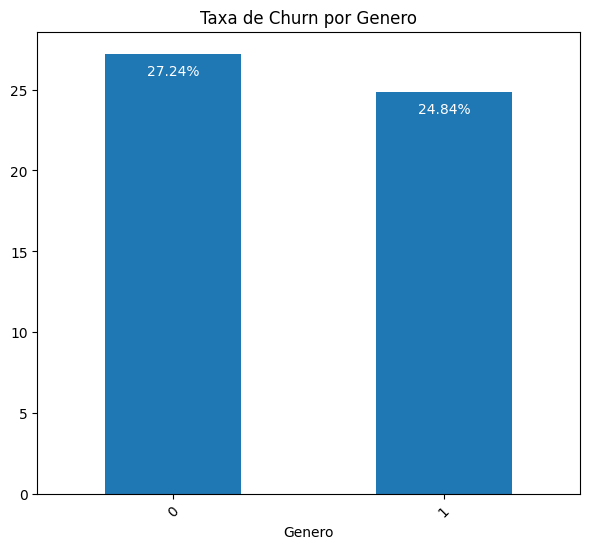

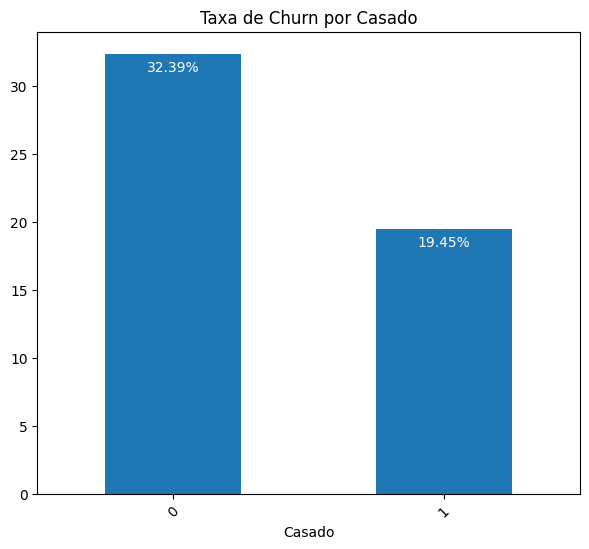

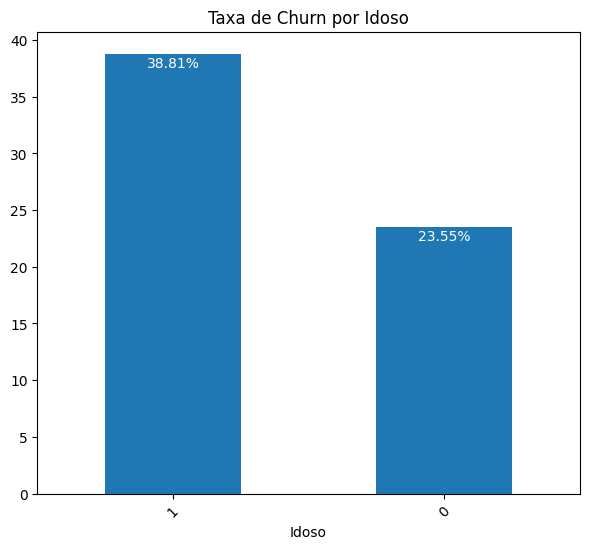

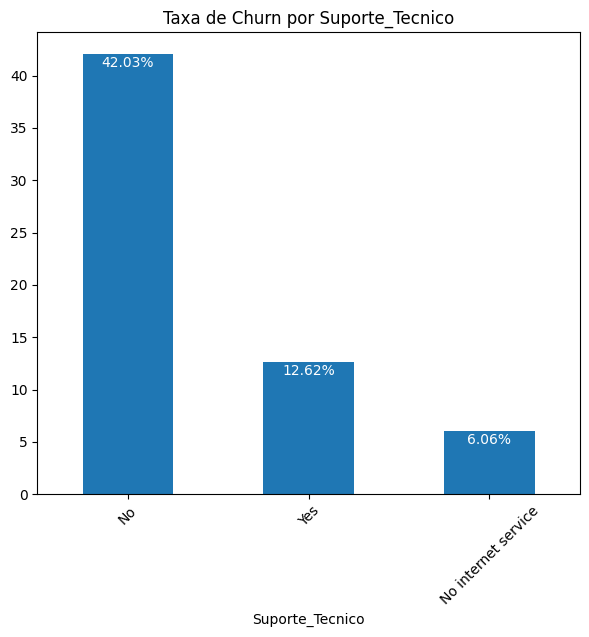

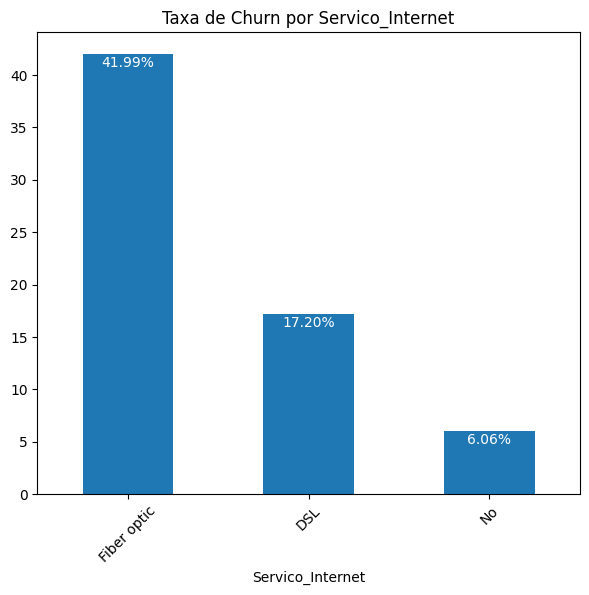

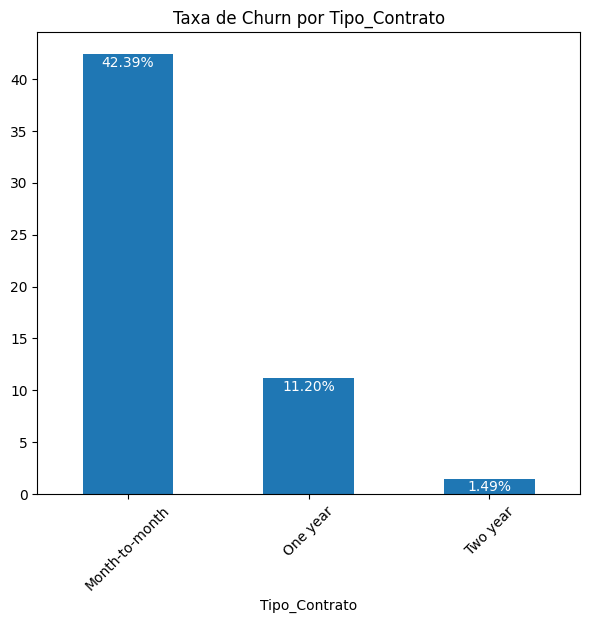

In [14]:
cols = ['Genero', 'Casado', 'Idoso', 'Suporte_Tecnico', 'Servico_Internet', 'Tipo_Contrato']
target = 'Churn'

for col in cols:
    average_target_col = df.groupby(col)[target].mean()
    rate = (average_target_col * 100).sort_values(ascending=False).round(2)
    
    ax = rate.plot(kind='bar', figsize=(7,6))
    
    for i, v in enumerate(rate):
        ax.text(i, v - 1.5, f'{v:.2f}%', ha='center', va='bottom', color='white')
    plt.title(f'Taxa de Churn por {col}')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

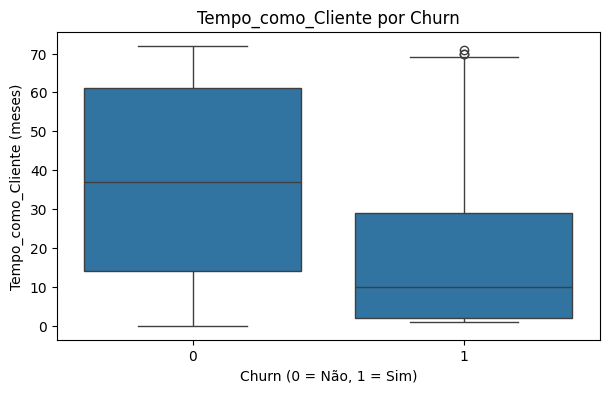

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,1846.0,37.408992,24.252044,0.0,14.0,37.0,61.0,72.0
1,649.0,17.976888,19.522330,1.0,2.0,10.0,29.0,71.0


In [15]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x='Churn', y='Tempo_como_Cliente')
plt.title("Tempo_como_Cliente por Churn")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Tempo_como_Cliente (meses)")
plt.show()

df.groupby('Churn')['Tempo_como_Cliente'].describe()

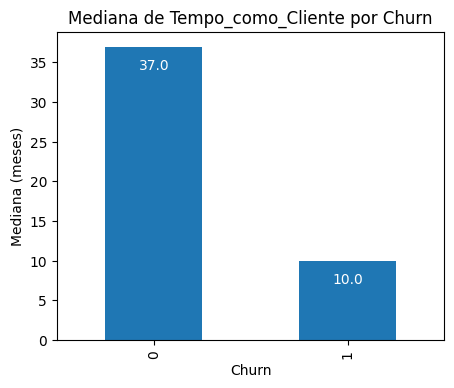

In [16]:
med = df.groupby('Churn')['Tempo_como_Cliente'].median()

ax = med.plot(kind='bar', figsize=(5,4))
for i, v in enumerate(med):
        ax.text(i, v - 1.5, f'{v:.1f}', ha='center', va='top', color='white')
plt.title("Mediana de Tempo_como_Cliente por Churn")
plt.xlabel("Churn")
plt.ylabel("Mediana (meses)")
plt.show()

**1. Gênero influencia churn?**

* A taxa de churn é 27,24% para Genero = 0 e 24,84% para Genero = 1.
* A diferença é de aproximadamente 2,4 pontos percentuais, o que sugere um efeito pequeno, gênero parece ter baixa influência no churn quando comparado a outras variáveis do dataset.

**2. Estado civil influencia churn?**

* Para Casado = 0, a taxa de churn é 32,39%, enquanto para Casado = 1 é 19,45%.
* Diferença de cerca de 12,94 pontos percentuais, indicando que clientes não casados apresentam churn significativamente maior.
* Isso sugere que o perfil familiar pode estar associado à retenção.

**3. Idosos são mais propensos ao churn?**

* Idoso = 1 apresenta churn de 38,81%, enquanto Idoso = 0 tem 23,55%.
* Diferença de aproximadamente 15,26 pontos percentuais, sugerindo que ser idoso está fortemente associado a maior probabilidade de churn.

**4. Suporte técnico reduz churn?**

* Clientes com Suporte_Tecnico = No, apresentam churn muito alto (42,03%).
* Já clientes com Suporte_Tecnico = Yes têm churn bem menor (12,62%).
* O grupo No internet service tem churn ainda menor (6,06%), possivelmente porque são clientes com outro perfil de consumo/contrato.
* No geral, os dados sugerem fortemente que ter suporte técnico está associado a menor churn (diferença de 29,41 pontos percentuais entre “No” e “Yes”).

“Obs.: No internet service representa clientes sem internet, portanto é um perfil diferente de No (clientes com internet, mas sem suporte). A comparação mais direta do efeito do suporte é entre Yes e No.”

**5. Tipo de internet está associado ao churn?**

* Fiber optic apresenta churn de 41,99%, bem acima de DSL (17,20%) e de No (6,06%).
* A diferença 24,79 pontos percentuais entre Fiber optic e DSL, isso sugere que clientes de fibra estão muito mais propensos ao churn, o que pode indicar diferenças de perfil, preço, expectativa de qualidade ou combinações de serviços/contrato.

**6. Tipo de contrato afeta churn?**

* Month-to-month tem churn de 42,39%, muito maior do que One year (11,20%) e Two year (1,49%).
* Isso confirma a hipótese clássica: contratos mais curtos facilitam cancelamento, enquanto contratos longos aumentam retenção.
* É uma das variáveis mais fortes do seu conjunto (diferença de 31,19 pontos percentuais entre “Month-to-month” e “One year”).

**7. Clientes com mais tempo de empresa dão menos churn?**

* O boxplot indica que clientes com Churn = 1 tendem a ter menor Tempo_como_Cliente do que clientes com Churn = 0.
* Isso sugere que o churn ocorre com mais frequência em clientes mais recentes, enquanto clientes com maior tempo de permanência são mais estáveis.

# 5) Quais variáveis parecem mais importantes para churn?

* As variáveis com associação mais forte ao churn foram: Tipo_Contrato, Suporte_Tecnico e Servico_Internet, pois apresentam as maiores diferenças de taxa entre categorias, sendo Suporte_Tecnico e Tipo_Contrato acima de 25 pontos percentuais.
* Em seguida, Idoso e Casado também mostram diferenças relevantes (acima de 10 pontos percentuais.).
* Genero apresentou a menor diferença (2,4 pontos percentuais), sugerindo menor poder explicativo isoladamente.